In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_customer_data.csv to cleaned_customer_data.csv
Saving cleaned_inventory_data.csv to cleaned_inventory_data.csv
Saving cleaned_product_data.csv to cleaned_product_data.csv
Saving cleaned_sales_data.csv to cleaned_sales_data.csv


In [3]:
sales_df = pd.read_csv("cleaned_sales_data.csv")

print("Dataset Shape:", sales_df.shape)
print("\nColumns:")
print(sales_df.columns.tolist())

Dataset Shape: (5000, 19)

Columns:
['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Product_Name', 'Category', 'Quantity', 'Selling_Price', 'Cost_Price', 'Discount_Percent', 'Gross_Sales', 'Discount_Amount', 'Revenue', 'Total_Cost', 'Profit', 'Profit_Margin_Percent', 'Payment_Mode', 'Sales_Channel', 'City']


In [4]:
sales_df["Order_Date"] = pd.to_datetime(sales_df["Order_Date"])

sales_df["Month"] = sales_df["Order_Date"].dt.to_period("M")

monthly_data = sales_df.groupby("Month").agg(
    Revenue=("Revenue", "sum"),
    Total_Orders=("Order_ID", "count"),
    Total_Quantity=("Quantity", "sum"),
    Average_Selling_Price=("Selling_Price", "mean"),
    Average_Discount=("Discount_Percent", "mean")
).reset_index()

monthly_data["Month"] = monthly_data["Month"].astype(str)

print("Monthly Dataset Shape:", monthly_data.shape)
print("\nMonthly Data:")
print(monthly_data.head())

Monthly Dataset Shape: (30, 6)

Monthly Data:
     Month    Revenue  Total_Orders  Total_Quantity  Average_Selling_Price  \
0  2024-01  1057367.5           166             387            3000.361446   
1  2024-02   864723.5           136             318            2991.102941   
2  2024-03  1059854.5           186             437            2714.408602   
3  2024-04  1348028.0           211             459            3175.071090   
4  2024-05  1027435.0           155             369            2955.354839   

   Average_Discount  
0          7.409639  
1          7.794118  
2          7.822581  
3          6.824645  
4          7.387097  


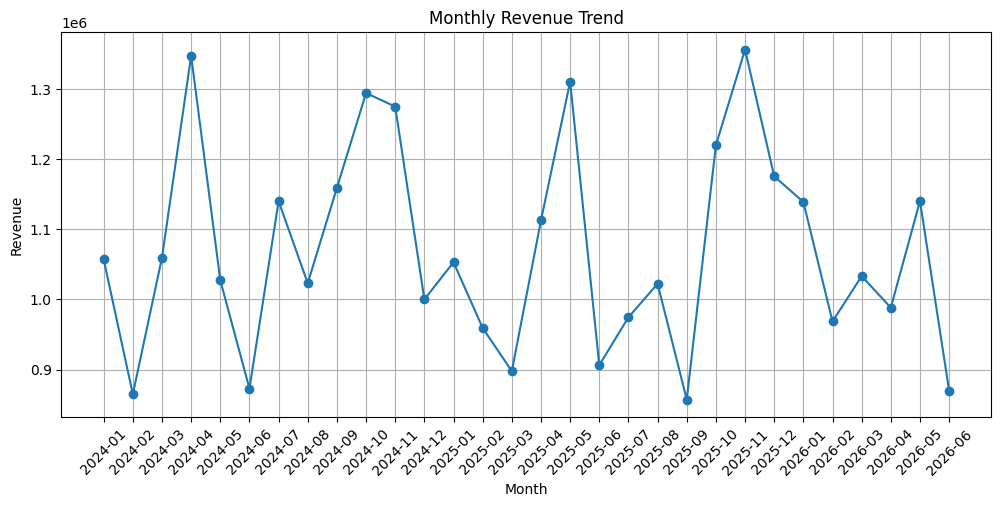

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_data["Month"],
    monthly_data["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [6]:
# Create a numerical time index
monthly_data["Month_Index"] = np.arange(len(monthly_data))

# Create previous-month (lag) features
monthly_data["Previous_Revenue"] = monthly_data["Revenue"].shift(1)
monthly_data["Previous_Orders"] = monthly_data["Total_Orders"].shift(1)
monthly_data["Previous_Quantity"] = monthly_data["Total_Quantity"].shift(1)
monthly_data["Previous_Avg_Price"] = monthly_data["Average_Selling_Price"].shift(1)
monthly_data["Previous_Avg_Discount"] = monthly_data["Average_Discount"].shift(1)

# Remove the first row because it has no previous-month data
model_data = monthly_data.dropna().reset_index(drop=True)

# Select features and target
features = [
    "Month_Index",
    "Previous_Revenue",
    "Previous_Orders",
    "Previous_Quantity",
    "Previous_Avg_Price",
    "Previous_Avg_Discount"
]

X = model_data[features]
y = model_data["Revenue"]

print("Features Used:")
print(features)

print("\nFeature Dataset Shape:", X.shape)
print("Target Dataset Shape:", y.shape)

print("\nModel Data Preview:")
print(model_data[["Month"] + features + ["Revenue"]].head())

Features Used:
['Month_Index', 'Previous_Revenue', 'Previous_Orders', 'Previous_Quantity', 'Previous_Avg_Price', 'Previous_Avg_Discount']

Feature Dataset Shape: (29, 6)
Target Dataset Shape: (29,)

Model Data Preview:
     Month  Month_Index  Previous_Revenue  Previous_Orders  Previous_Quantity  \
0  2024-02            1         1057367.5            166.0              387.0   
1  2024-03            2          864723.5            136.0              318.0   
2  2024-04            3         1059854.5            186.0              437.0   
3  2024-05            4         1348028.0            211.0              459.0   
4  2024-06            5         1027435.0            155.0              369.0   

   Previous_Avg_Price  Previous_Avg_Discount    Revenue  
0         3000.361446               7.409639   864723.5  
1         2991.102941               7.794118  1059854.5  
2         2714.408602               7.822581  1348028.0  
3         3175.071090               6.824645  1027435.0  
4   

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Data: (23, 6)
Testing Data: (6, 6)
Training Target: (23,)
Testing Target: (6,)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature normalization completed successfully.")

print("\nScaled Training Data (first 5 rows):")
print(X_train_scaled[:5])

Feature normalization completed successfully.

Scaled Training Data (first 5 rows):
[[ 0.85883034  1.34149132  0.52166724  1.92916978 -1.23746923  0.16714709]
 [-1.56698868  0.08130623  0.01469485 -0.01100287  0.40919009 -0.2528528 ]
 [ 1.43640629 -0.10419995  0.24001591  0.32641846 -0.76397815  1.78246853]
 [-0.0652912  -0.67677066 -0.49227754 -1.12871102  1.80656066  0.74528418]
 [ 0.16573919  0.51068691  0.35267645  0.07335246  0.44842533  0.86854061]]


Feature Correlation Matrix:
                       Month_Index  Previous_Revenue  Previous_Orders  \
Month_Index                   1.00              0.04            -0.06   
Previous_Revenue              0.04              1.00             0.66   
Previous_Orders              -0.06              0.66             1.00   
Previous_Quantity             0.07              0.92             0.64   
Previous_Avg_Price           -0.25              0.12             0.10   
Previous_Avg_Discount         0.13             -0.25             0.06   

                       Previous_Quantity  Previous_Avg_Price  \
Month_Index                         0.07               -0.25   
Previous_Revenue                    0.92                0.12   
Previous_Orders                     0.64                0.10   
Previous_Quantity                   1.00               -0.20   
Previous_Avg_Price                 -0.20                1.00   
Previous_Avg_Discount              -0.13               -0.29   

           

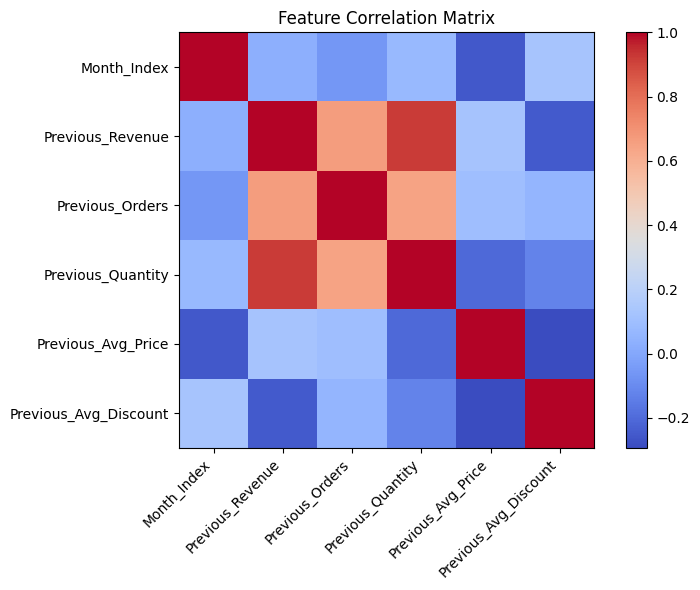

In [9]:
correlation_matrix = X.corr()

print("Feature Correlation Matrix:")
print(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [10]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


In [11]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully.")

print("\nActual vs Predicted Revenue:")
comparison = pd.DataFrame({
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": y_pred
})

print(comparison.round(2))

Predictions generated successfully.

Actual vs Predicted Revenue:
   Actual_Revenue  Predicted_Revenue
0       1140631.5          996239.97
1        906199.5         1038996.74
2        959303.0         1086115.99
3       1175836.5         1099586.12
4       1294800.0         1109374.06
5       1275461.0         1106508.04


In [12]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("----------------------------")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Model Performance
----------------------------
RMSE: 143357.10
R² Score: 0.0488


In [13]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("5-Fold Cross-Validation R² Scores:")
print(cv_scores.round(4))

print("\nAverage Cross-Validation R²:",
      round(cv_scores.mean(), 4))


5-Fold Cross-Validation R² Scores:
[-0.3091 -0.6876  0.1122 -0.0711 -5.2462]

Average Cross-Validation R²: -1.2404


In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regression", LinearRegression())
])

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
poly_r2 = r2_score(y_test, poly_pred)

print("Polynomial Regression Performance")
print("----------------------------")
print(f"RMSE: {poly_rmse:.2f}")
print(f"R² Score: {poly_r2:.4f}")


Polynomial Regression Performance
----------------------------
RMSE: 588682.55
R² Score: -15.0404


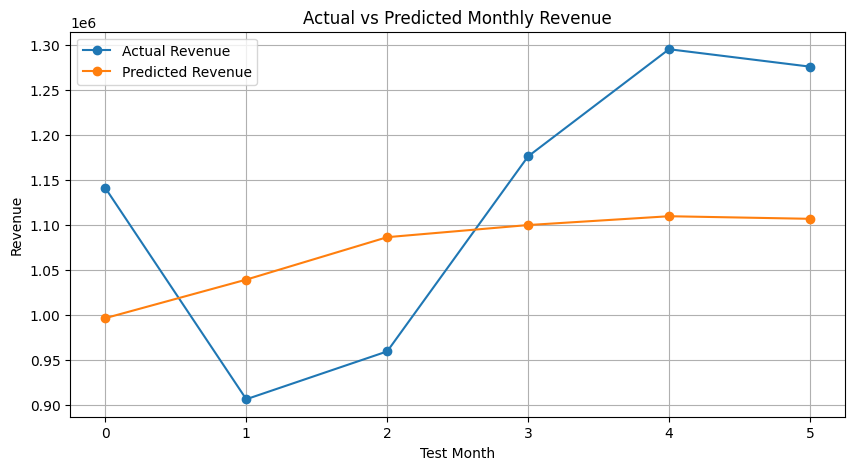

In [15]:
comparison = pd.DataFrame({
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": y_pred
})

plt.figure(figsize=(10, 5))

plt.plot(
    comparison["Actual_Revenue"].values,
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    comparison["Predicted_Revenue"].values,
    marker="o",
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Monthly Revenue")
plt.xlabel("Test Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
comparison["Error"] = comparison["Actual_Revenue"] - comparison["Predicted_Revenue"]
comparison["Absolute_Error"] = abs(comparison["Error"])

print("Prediction Error Analysis:")
print(comparison.round(2))

print("\nAverage Absolute Error:",
      round(comparison["Absolute_Error"].mean(), 2))


Prediction Error Analysis:
   Actual_Revenue  Predicted_Revenue      Error  Absolute_Error
0       1140631.5          996239.97  144391.53       144391.53
1        906199.5         1038996.74 -132797.24       132797.24
2        959303.0         1086115.99 -126812.99       126812.99
3       1175836.5         1099586.12   76250.38        76250.38
4       1294800.0         1109374.06  185425.94       185425.94
5       1275461.0         1106508.04  168952.96       168952.96

Average Absolute Error: 139105.17


In [18]:
print("===== Week 4 Final Model Validation Summary =====\n")

print(f"Linear Regression RMSE: ₹{rmse:,.2f}")
print(f"Linear Regression R² Score: {r2:.4f}")
print(f"5-Fold Cross-Validation R²: {cv_scores.mean():.4f}")
print(f"Average Absolute Error: ₹{comparison['Absolute_Error'].mean():,.2f}")

print("\nPolynomial Regression:")
print(f"RMSE: ₹{poly_rmse:,.2f}")
print(f"R² Score: {poly_r2:.4f}")

print("\nModel Evaluation:")
if r2 > poly_r2:
    print("✓ Linear Regression performed better than Polynomial Regression.")
else:
    print("✓ Polynomial Regression performed better than Linear Regression.")

print("\nWeek 4 Predictive Modeling task completed successfully!")

===== Week 4 Final Model Validation Summary =====

Linear Regression RMSE: ₹143,357.10
Linear Regression R² Score: 0.0488
5-Fold Cross-Validation R²: -1.2404
Average Absolute Error: ₹139,105.17

Polynomial Regression:
RMSE: ₹588,682.55
R² Score: -15.0404

Model Evaluation:
✓ Linear Regression performed better than Polynomial Regression.

Week 4 Predictive Modeling task completed successfully!


In [19]:
print("===== Business Interpretation & Recommendations =====\n")

print("1. The Linear Regression model provides a baseline for monthly revenue prediction.")
print("2. The model's validation results show that the current features do not strongly explain")
print("   the variation in monthly revenue.")
print("3. The model should therefore be treated as an initial predictive baseline rather than")
print("   a final production forecasting model.")
print("4. Additional business factors such as marketing activity, seasonal patterns,")
print("   product-level demand, customer behavior, and external market conditions")
print("   can improve future predictions.")
print("5. Businesses can use predictive analysis together with dashboards and historical")
print("   trends to support sales planning, inventory decisions, and target setting.")
print("6. Predictions should be combined with business knowledge and current market")
print("   conditions before making important decisions.")

print("\nKey Recommendation:")
print("Improve the forecasting model by incorporating more historical and business")
print("features before deploying it as a final SME decision-support tool.")


===== Business Interpretation & Recommendations =====

1. The Linear Regression model provides a baseline for monthly revenue prediction.
2. The model's validation results show that the current features do not strongly explain
   the variation in monthly revenue.
3. The model should therefore be treated as an initial predictive baseline rather than
   a final production forecasting model.
4. Additional business factors such as marketing activity, seasonal patterns,
   product-level demand, customer behavior, and external market conditions
   can improve future predictions.
5. Businesses can use predictive analysis together with dashboards and historical
   trends to support sales planning, inventory decisions, and target setting.
6. Predictions should be combined with business knowledge and current market
   conditions before making important decisions.

Key Recommendation:
Improve the forecasting model by incorporating more historical and business
features before deploying it as a fin